Dans ce point de contrôle, nous analyserons le Diabète Dataset, qui contient des informations médicales et démographiques relatives au diabète.

Instructions
Dataset description:
 Ce dataset comprend des mesures médicales et des indicateurs qui peuvent aider à diagnostiquer le diabète. L'objectif est d'explorer l'ensemble de données et de découvrir des modèles, des corrélations et des problèmes potentiels tels que des valeurs manquantes ou des valeurs aberrantes.

Dataset Columns Description
Pregnancies : Nombre de fois où la patiente a été enceinte.
Glucose : Concentration plasmatique de glucose (2 heures lors d'un test de tolérance au glucose par voie orale).
BloodPressure : Pression artérielle diastolique (mm Hg).
Épaisseur de la peau : Épaisseur du pli cutané du triceps (mm).
Insuline : Insuline sérique sur 2 heures (mu U/ml).
IMC : Indice de masse corporelle (poids en kg/(taille en m)^2).
Fonction généalogique du diabète : Fonction généalogique du diabète (mesure de l'influence génétique).
Age : Âge du patient (années).
Outcome : Résultat du diagnostic de diabète (0 = Non, 1 = Oui).

Étape 1 : Exploration des données avec Pandas

 Chargez le jeu de données:

Utilisez Pandas pour charger le jeu de données dans un DataFrame.
Assurez-vous que le jeu de données se charge correctement en vérifiant les premières lignes à l'aide de head().

Affichez la structure du jeu de données, y compris les noms des colonnes, les types de données et l'utilisation de la mémoire.
Identifiez le nombre de valeurs manquantes ou de zéros dans l'ensemble de données.

Utilisez la fonction describe() pour analyser:

Statistiques sommaires pour chaque colonne (moyenne, min, max, quartiles).
Recherchez les irrégularités, telles que les colonnes présentant des valeurs minimales ou maximales irréalistes.

Étape 2 : Exploration des données avec ydata-profiling
Générer un rapport de profilage:
Utilisez ydata-profiling pour créer un rapport interactif qui comprend:
Descriptions des colonnes (type, valeurs uniques, valeurs manquantes).
Distributions pour les colonnes numériques.
Matrices de corrélation pour identifier les relations entre les variables.
Mise en évidence des valeurs aberrantes ou des anomalies.

Analyser le rapport:

Identifier les valeurs manquantes dans les colonnes clés telles que Glucose, Insuline, et IMC.
Examinez les corrélations entre des colonnes telles que l'âge, la glycémie et le résultat.
Notez tout aperçu ou modèle intéressant (par ex, des niveaux de glucose plus élevés sont en corrélation avec un diagnostic de diabète).
Documenter les résultats:

Rédigez un résumé des principales observations tirées de Pandas et du rapport de profilage de ydata.
Mentionnez:
 Modèles ou tendances en matière de glucose, d'IMC ou de grossesses.
Des problèmes tels que des valeurs manquantes ou nulles dans des colonnes critiques.

Suggestions:
 Recommander les prochaines étapes, telles que le traitement des valeurs manquantes, des valeurs aberrantes ou la modélisation prédictive des données.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration pour l'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("="*80)
print("ANALYSE DU DATASET DIABÈTE")
print("="*80)

# ÉTAPE 1: Chargement des données
print("\n1. CHARGEMENT DES DONNÉES")
print("-"*40)

# Charger le dataset (en spécifiant le séparateur ';' et en ignorant la première ligne)
df = pd.read_csv('Analyse du Diabète Dataset.csv', sep=';', skiprows=1)

print("Aperçu des 5 premières lignes:")
print(df.head())

print("\nDimensions du dataset:", df.shape)
print(f"Nombre d'observations: {df.shape[0]}")
print(f"Nombre de variables: {df.shape[1]}")

# ÉTAPE 2: Structure du dataset
print("\n2. STRUCTURE DU DATASET")
print("-"*40)

print("\nInformations sur les colonnes et types de données:")
print(df.info())

print("\nNoms des colonnes:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

# ÉTAPE 3: Valeurs manquantes et zéros
print("\n3. ANALYSE DES VALEURS MANQUANTES ET ZÉROS")
print("-"*40)

# Vérifier les valeurs manquantes (NaN)
print("Valeurs manquantes (NaN) par colonne:")
print(df.isnull().sum())

# Vérifier les zéros dans les colonnes où ils ne devraient pas apparaître
colonnes_medicales = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("\nValeurs égales à zéro dans les colonnes médicales:")
for col in colonnes_medicales:
    nb_zeros = (df[col] == 0).sum()
    pourcentage = (nb_zeros / len(df)) * 100
    print(f"{col:20s}: {nb_zeros:3d} zéros ({pourcentage:.1f}%)")

# ÉTAPE 4: Statistiques descriptives
print("\n4. STATISTIQUES DESCRIPTIVES")
print("-"*40)

print("Résumé statistique du dataset:")
print(df.describe())

# ÉTAPE 5: Analyse plus détaillée par Outcome (diabète ou non)
print("\n5. ANALYSE COMPARATIVE PAR OUTCOME")
print("-"*40)

# Séparer les données par outcome
diabetique = df[df['Outcome'] == 1]
non_diabetique = df[df['Outcome'] == 0]

print(f"Personnes non diabétiques (Outcome=0): {len(non_diabetique)}")
print(f"Personnes diabétiques (Outcome=1): {len(diabetique)}")
print(f"Pourcentage de diabétiques: {(len(diabetique)/len(df)*100):.1f}%")

# Comparaison des moyennes
print("\nComparaison des moyennes entre groupes:")
comparaison = pd.DataFrame({
    'Non Diabétique': non_diabetique.mean(),
    'Diabétique': diabetique.mean(),
    'Différence': diabetique.mean() - non_diabetique.mean()
})
print(comparaison)

# ÉTAPE 6: Corrélations
print("\n6. ANALYSE DES CORRÉLATIONS")
print("-"*40)

# Calculer la matrice de corrélation
correlation_matrix = df.corr()

print("Corrélations avec la variable Outcome:")
outcome_corr = correlation_matrix['Outcome'].sort_values(ascending=False)
print(outcome_corr)

# ÉTAPE 7: Identification des valeurs aberrantes (méthode IQR)
print("\n7. IDENTIFICATION DES VALEURS ABERRANTES")
print("-"*40)

def detecter_outliers(df, colonne):
    Q1 = df[colonne].quantile(0.25)
    Q3 = df[colonne].quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    outliers = df[(df[colonne] < borne_inf) | (df[colonne] > borne_sup)]
    return len(outliers), borne_inf, borne_sup

print("Analyse des valeurs aberrantes (outliers) par colonne:")
for col in df.columns:
    if col != 'Outcome':  # Exclure la variable cible
        nb_outliers, borne_inf, borne_sup = detecter_outliers(df, col)
        pourcentage = (nb_outliers / len(df)) * 100
        print(f"{col:25s}: {nb_outliers:3d} outliers ({pourcentage:.1f}%)")

# ÉTAPE 8: Visualisations (si vous exécutez dans un environnement avec matplotlib)
print("\n8. CRÉATION DE VISUALISATIONS")
print("-"*40)
print("Les visualisations seront générées si vous exécutez ce code dans un environnement avec matplotlib.")

# Création de quelques graphiques
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Distribution de Glucose par Outcome
axes[0, 0].hist([non_diabetique['Glucose'], diabetique['Glucose']],
                label=['Non Diabétique', 'Diabétique'], alpha=0.7, bins=20)
axes[0, 0].set_xlabel('Glucose')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].set_title('Distribution du Glucose par Outcome')
axes[0, 0].legend()

# Distribution de BMI par Outcome
axes[0, 1].hist([non_diabetique['BMI'], diabetique['BMI']],
                label=['Non Diabétique', 'Diabétique'], alpha=0.7, bins=20)
axes[0, 1].set_xlabel('IMC')
axes[0, 1].set_ylabel('Fréquence')
axes[0, 1].set_title('Distribution de l\'IMC par Outcome')
axes[0, 1].legend()

# Distribution d'Age par Outcome
axes[0, 2].hist([non_diabetique['Age'], diabetique['Age']],
                label=['Non Diabétique', 'Diabétique'], alpha=0.7, bins=15)
axes[0, 2].set_xlabel('Âge')
axes[0, 2].set_ylabel('Fréquence')
axes[0, 2].set_title('Distribution de l\'Âge par Outcome')
axes[0, 2].legend()

# Boxplot Glucose
axes[1, 0].boxplot([non_diabetique['Glucose'], diabetique['Glucose']],
                   labels=['Non Diabétique', 'Diabétique'])
axes[1, 0].set_ylabel('Glucose')
axes[1, 0].set_title('Boxplot du Glucose')

# Boxplot BMI
axes[1, 1].boxplot([non_diabetique['BMI'], diabetique['BMI']],
                   labels=['Non Diabétique', 'Diabétique'])
axes[1, 1].set_ylabel('IMC')
axes[1, 1].set_title('Boxplot de l\'IMC')

# Matrice de corrélation (heatmap)
im = axes[1, 2].imshow(correlation_matrix, cmap='coolwarm', aspect='auto')
axes[1, 2].set_xticks(range(len(correlation_matrix.columns)))
axes[1, 2].set_yticks(range(len(correlation_matrix.columns)))
axes[1, 2].set_xticklabels(correlation_matrix.columns, rotation=45, ha='right')
axes[1, 2].set_yticklabels(correlation_matrix.columns)
axes[1, 2].set_title('Matrice de Corrélation')
plt.colorbar(im, ax=axes[1, 2])

plt.tight_layout()
plt.savefig('analyse_diabete_visualisations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("SYNTHÈSE DE L'ANALYSE")
print("="*80)


ANALYSE DU DATASET DIABÈTE

1. CHARGEMENT DES DONNÉES
----------------------------------------


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe8 in position 15: invalid continuation byte

In [25]:
df = pd.read_csv('/content/diabetes (1).csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [26]:
print("\nInformations sur le DataFrame :")
print(df.info())


Informations sur le DataFrame :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


Observations :

Le dataset contient 768 observations et 9 colonnes.

Toutes les colonnes sont de type numérique (int64 pour 'Pregnancies' et 'Outcome', float64 pour les autres).

Aucune valeur manquante (Non-Null Count est de 768 pour toutes les colonnes). Cependant, la présence de zéros dans des colonnes comme 'Glucose', 'BloodPressure' ou 'Insulin' peut indiquer des données manquantes ou non valides.

In [27]:
##2. Analyse des valeurs nulles ou aberrantes (zéros)
# Compter les zéros dans les colonnes où ils ne devraient pas logiquement apparaître
colonnes_avec_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in colonnes_avec_zero:
    nb_zeros = (df[col] == 0).sum()
    print(f"Nombre de zéros dans {col}: {nb_zeros}")

Nombre de zéros dans Glucose: 5
Nombre de zéros dans BloodPressure: 35
Nombre de zéros dans SkinThickness: 227
Nombre de zéros dans Insulin: 374
Nombre de zéros dans BMI: 11


Résultats :

Glucose : 5 zéros (devrait être > 0)

BloodPressure : 35 zéros (une pression artérielle ne peut être nulle)

SkinThickness : 227 zéros (valeur physiologiquement improbable)

Insulin : 374 zéros (beaucoup de valeurs manquantes ou non mesurées)

BMI : 11 zéros (un IMC de 0 est impossible)

Conclusion : Ces zéros sont très probablement des valeurs manquantes ou des données non enregistrées, et devront être traités.

In [28]:
##3. Analyse descriptive avec describe
df.describe(include = 'all').T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


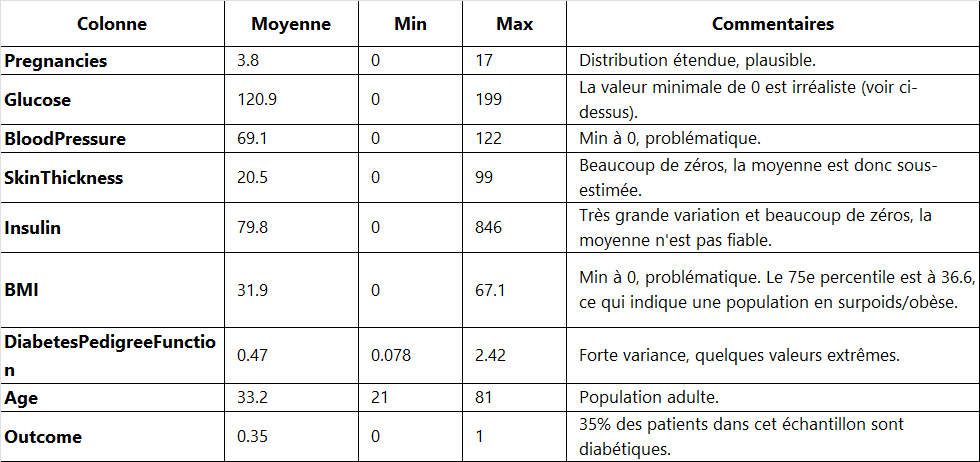

In [29]:
## Étape 2 : Exploration des données avec ydata-profiling

# Install ydata-profiling if not already installed
!pip install ydata-profiling

## Génération du rapport
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Rapport de Profilage - Diabète Dataset", explorative=True)
profile.to_file("rapport_diabete.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 9/9 [00:00<00:00, 108.71it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

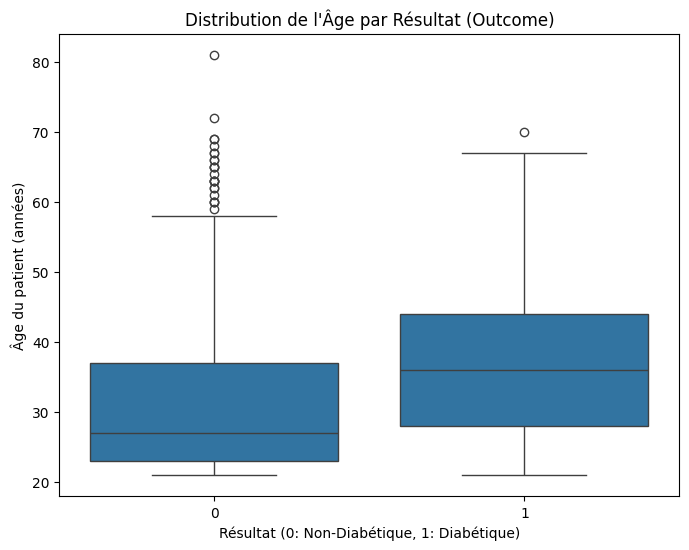

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='Outcome', y='Age', data=df)
plt.title('Distribution de l\'Âge par Résultat (Outcome)')
plt.xlabel('Résultat (0: Non-Diabétique, 1: Diabétique)')
plt.ylabel('Âge du patient (années)')
plt.show()

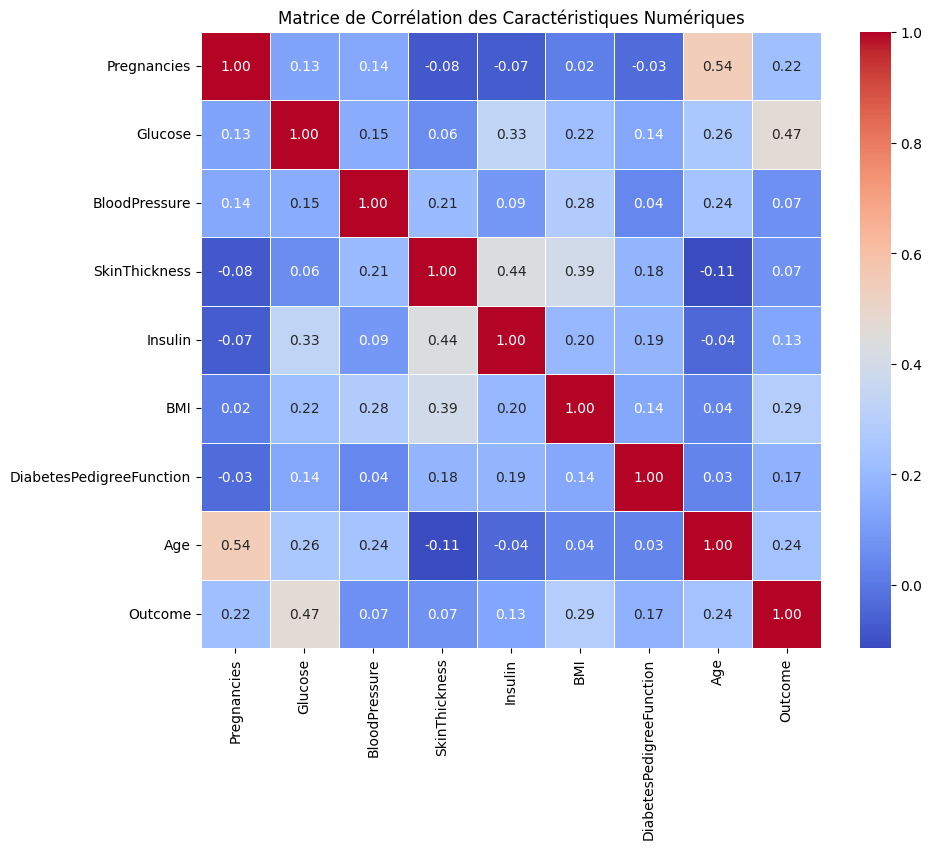

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matrice de Corrélation des Caractéristiques Numériques')
plt.show()

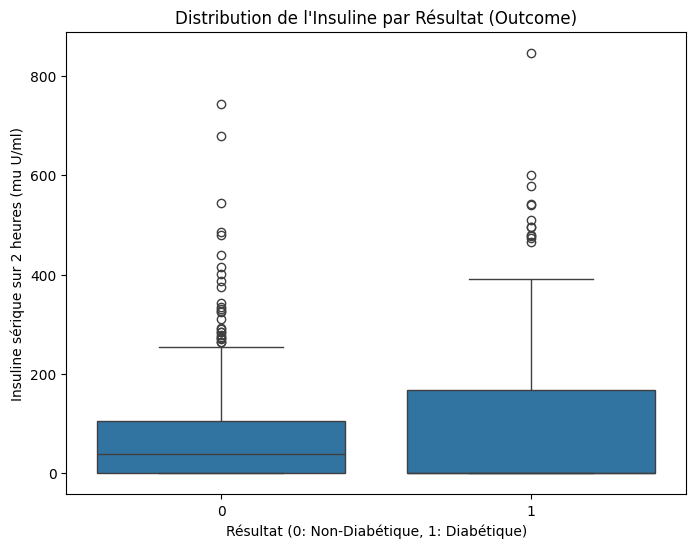

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='Outcome', y='Insulin', data=df)
plt.title('Distribution de l\'Insuline par Résultat (Outcome)')
plt.xlabel('Résultat (0: Non-Diabétique, 1: Diabétique)')
plt.ylabel('Insuline sérique sur 2 heures (mu U/ml)')
plt.show()

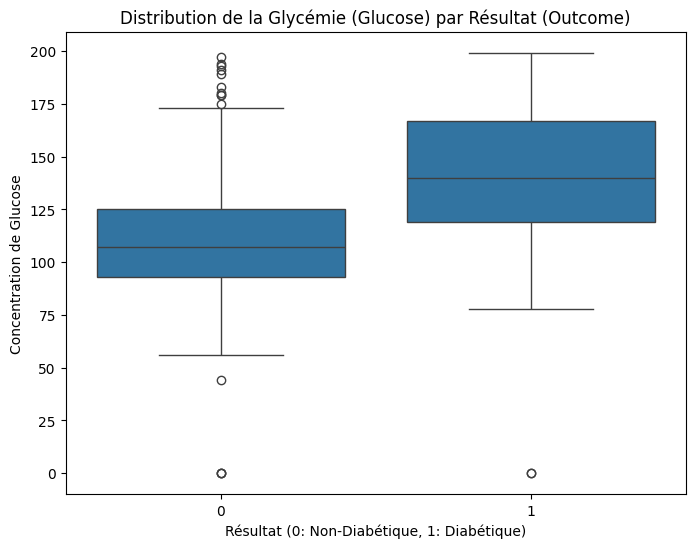

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title('Distribution de la Glycémie (Glucose) par Résultat (Outcome)')
plt.xlabel('Résultat (0: Non-Diabétique, 1: Diabétique)')
plt.ylabel('Concentration de Glucose')
plt.show()

**Analyse du rapport et résultats documentés
Le rapport généré permet une analyse visuelle et approfondie.**
1. Aperçu général du dataset
Nombre de variables : 9

Nombre d'observations : 768

Valeurs manquantes (codées comme NaN) : 0%

Valeurs nulles ou aberrantes (zéros) : Mises en évidence dans les colonnes 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI'.

2. Analyse univariée (distributions)
Glucose : Distribution bimodale, suggérant deux populations (personnes avec et sans diabète). Les quelques zéros sont des anomalies évidentes.

IMC : Distribution asymétrique à droite (skewness positive), avec une moyenne de 31.9, ce qui correspond à la catégorie "obésité".

Âge : Concentré entre 20 et 40 ans, avec une longue traîne vers les âges plus avancés.

Insuline et SkinThickness : Forte proportion de zéros, ce qui rend leurs distributions très difficiles à interpréter en l'état.

3. Analyse multivariée (corrélations)
La matrice de corrélation met en lumière les relations suivantes :

Facteurs les plus corrélés avec le diabète (Outcome) :

Glucose (0.47) : C'est de loin la variable la plus prédictive. Un taux de glucose élevé est fortement associé à un diagnostic de diabète.
IMC (0.29) : Corrélation positive modérée. Un IMC plus élevé augmente le risque de diabète.
Âge (0.24) : Corrélation positive. Le risque de diabète augmente avec l'âge.
Pregnancies (0.22) : Légère corrélation positive.
Autres corrélations notables :

Âge et Pregnancies (0.54) : Logique, plus une femme est âgée, plus elle a eu de grossesses.

SkinThickness et BMI (0.39) et Insulin et SkinThickness (0.44) : Des liens attendus entre la masse grasse, l'indice de masse corporelle et les niveaux d'insuline, mais ces corrélations sont affaiblies par la présence de nombreux zéros.

4. Détection des valeurs aberrantes
Le rapport signale de nombreuses valeurs extrêmes via l'analyse des quantiles et des boxplots, notamment dans les colonnes 'Insulin' (avec des pics jusqu'à 846) et 'DiabetesPedigreeFunction' (jusqu'à 2.42). Ces valeurs, bien qu'extrêmes, peuvent être cliniquement possibles et ne doivent pas être supprimées sans une analyse médicale plus approfondie.



**Synthèse et Recommandations**
**Principales observations
Problème majeur de données manquantes déguisées :**

 Les colonnes 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin' et 'BMI' contiennent des zéros qui sont physiologiquement impossibles. Ces valeurs doivent être traitées comme manquantes. 'Insulin' et 'SkinThickness' sont les plus touchées.

Facteurs de risque clés identifiés : L'analyse confirme les facteurs de risque connus du diabète. La concentration de glucose est le prédicteur le plus fort, suivie par l'IMC et l'âge.

Corrélations pertinentes : Les relations entre l'âge, les grossesses et les mesures corporelles (IMC, épaisseur de la peau) sont logiques et cohérentes.

Données déséquilibrées : La variable cible 'Outcome' présente un déséquilibre (35% de 1, 65% de 0). Cela devra être pris en compte lors de la modélisation.

**Suggestions pour la suite**
Nettoyage des données (Data Cleaning) :

Imputation des valeurs nulles : Remplacer les zéros des colonnes 'Glucose', 'BloodPressure', 'BMI' par la médiane de ces colonnes (en faisant attention de ne pas impacter les vrais zéros, mais il n'y en a pas ici). Pour 'SkinThickness' et 'Insulin', où le taux de zéros est très élevé, on pourrait envisager une imputation plus sophistiquée (par exemple, par régression ou en utilisant la médiane conditionnée par l'IMC), ou créer une colonne binaire indiquant si la valeur était manquante.

Gestion des valeurs aberrantes :

Analyser les valeurs extrêmes d'insuline et de 'DiabetesPedigreeFunction'. Il est souvent préférable de les conserver, mais d'utiliser des modèles robustes aux outliers ou d'appliquer une transformation (log, racine carrée) pour réduire leur impact.

Analyse plus poussée et modélisation :

Créer un modèle de classification (régression logistique, arbres de décision, forêts aléatoires) pour prédire le diabète en utilisant les variables nettoyées.

Évaluer la performance du modèle et l'importance des différentes caractéristiques (feature importance).

Tenir compte du déséquilibre des classes en utilisant des métriques comme le F1-score, la précision et le rappel, ou en utilisant des techniques de rééchantillonnage (SMOTE).

